# Bleaching report — interactive plots

Per-animal photobleaching diagnostics for one or more animals in a dataset. The single selection cell in section 2 is the only thing to edit when switching datasets or animals; everything downstream — load and the per-animal outputs — works against whatever the selection cell defined. Section 4 cells are thin caller stubs over `sollertia_forgery.analysis.bleaching.plotting`; edit the helpers in the package and re-run the affected cell to refresh.

## 1. Setup

Imports for the rest of the notebook. Run once per kernel restart; `%autoreload` keeps package edits live so re-running the section 4 cells picks up plotting helper changes without reloading.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
from ataraxis_base_utilities import LogLevel, console

from sollertia_forgery.shared_assets import DatasetData
from sollertia_forgery.analysis import (
    BleachingReport,
    plot_baseline_trend,
    plot_snr_distributions,
    plot_within_session,
    plot_within_session_average,
)

## 2. Selection

The only cell to edit when switching datasets or animals. `DATASET_PATH` is the dataset root; `ANIMALS` is either a tuple of animal ids (`("11", "15", "16")`) or `None` to load every animal in the dataset that has a saved bleaching report.

In [2]:
DATASET_PATH: Path = Path("/home/data/Data/void")
ANIMALS: tuple[str, ...] | None = ("11",)

## 3. Load

Reads the dataset and assembles `reports`, the per-animal `dict[str, BleachingReport]` consumed by every plot cell. Animals without a saved bleaching report are skipped with a warning so partial-evaluation datasets still load.

In [3]:
dataset = DatasetData.load(dataset_path=DATASET_PATH)
resolved_animals: tuple[str, ...] = (
    tuple(dataset_animal.animal for dataset_animal in dataset.animals)
    if ANIMALS is None
    else ANIMALS
)

reports: dict[str, BleachingReport] = {}
for animal_id in resolved_animals:
    dataset_animal = dataset.get_animal(animal=animal_id)
    try:
        reports[animal_id] = BleachingReport.load(animal=dataset_animal)
    except FileNotFoundError:
        console.echo(
            message=f"animal {animal_id}: no saved bleaching report; skipping",
            level=LogLevel.WARNING,
        )

console.echo(message=f"Dataset: {dataset.name} ({DATASET_PATH})", level=LogLevel.INFO)
console.echo(
    message=f"Loaded {len(reports)} bleaching report(s) for: {', '.join(reports) or '<none>'}",
    level=LogLevel.INFO,
)

2026-05-02 17:29:14.084 | INFO     | Dataset: void (/home/data/Data/void)
2026-05-02 17:29:14.085 | INFO     | Loaded 1 bleaching report(s) for: 11


## 4. Per-animal outputs

Each cell below loops over `reports` and calls one helper from `sollertia_forgery.analysis.bleaching.plotting`. Helpers return `matplotlib.figure.Figure`; the notebook just calls `plt.show()` so the figures render inline.

### 4.1 Text summary

In [4]:
for animal_id, report in reports.items():
    console.echo(message=f"Animal {animal_id} bleaching summary", level=LogLevel.INFO)
    report.print_summary()

2026-05-02 17:29:14.135 | INFO     | Animal 11 bleaching summary
Chronic Photobleaching Evaluation

Overview
--------
Sessions:         20 spanning 25 days (day 0 to 25)
Registered cells: 8179

Configuration
-------------
Baseline percentile:   8 (per-cell window: 60 s, FOV-mean window: 20 s)
SNR signal percentile: 95
Thresholds:            F0 loss > 30%, within-session drop > 20%, SNR loss > 30%

Across-session baseline fluorescence (chronic photobleaching)
-------------------------------------------------------------
Population F0 (first -> last):  2486.60 -> 2059.03
Fractional loss:                17.2%  [pass]

Within-session baseline (acute bleaching)
-----------------------------------------
Per-session drop median / max:  5.6% / 20.5%
Sessions above threshold:       1 / 20  [FAIL]

Per-cell SNR (signal-to-noise contrast across sessions)
-------------------------------------------------------
Population SNR (first -> last): 3.67 -> 3.34
Fractional loss:                8.9%  [pass

### 4.2 Across-session baseline trend

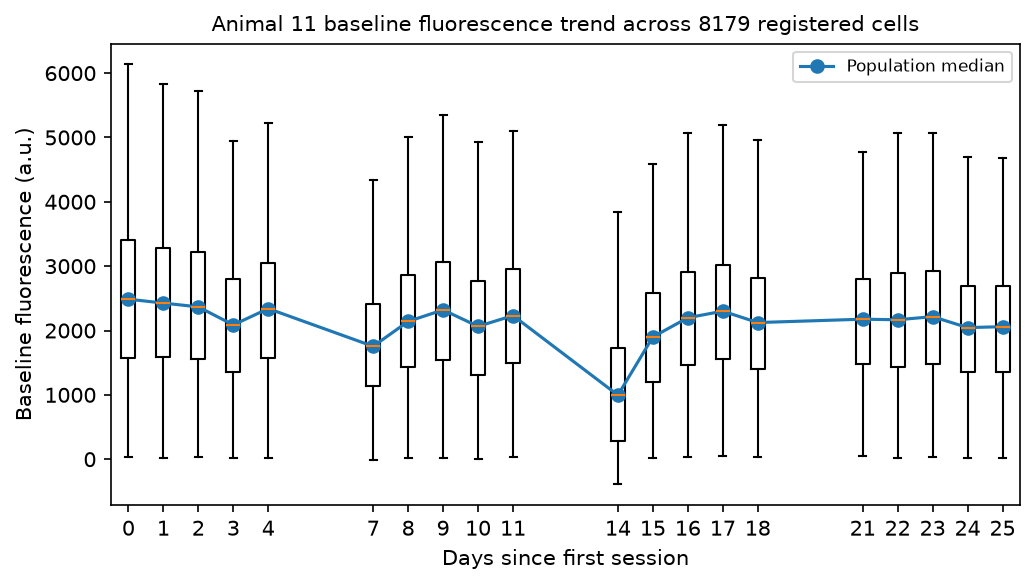

In [5]:
for animal_id, report in reports.items():
    plot_baseline_trend(report=report, animal_id=animal_id)
    plt.show()

### 4.3 Within-session bleaching (per-session traces)

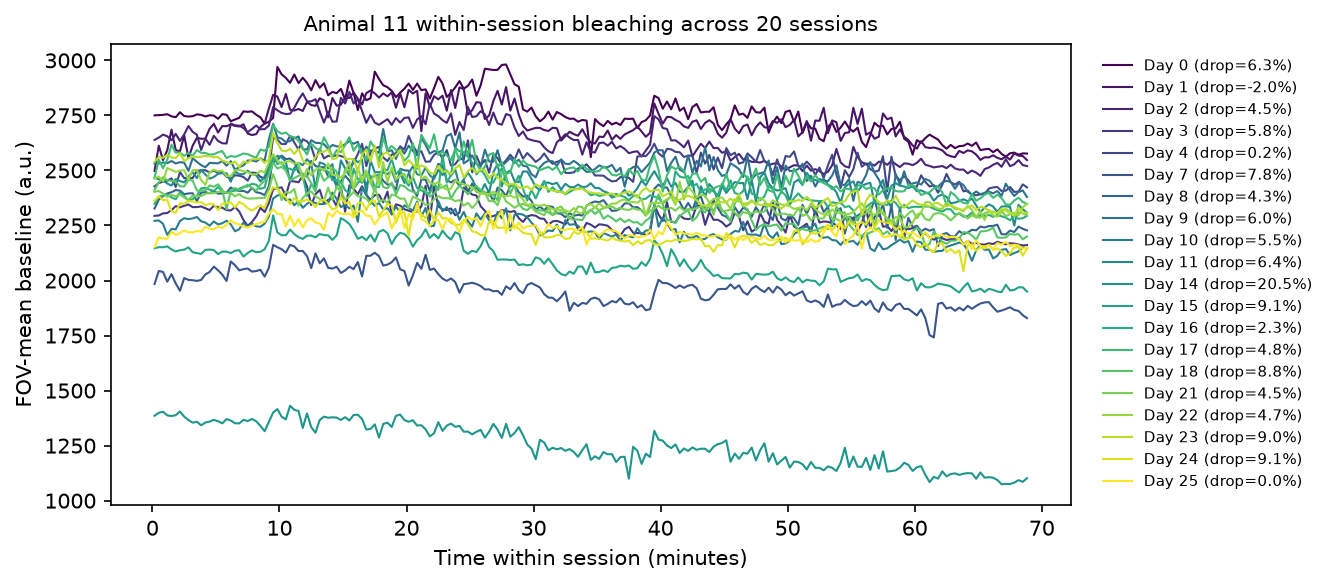

In [6]:
for animal_id, report in reports.items():
    plot_within_session(report=report, animal_id=animal_id)
    plt.show()

### 4.4 Within-session bleaching (across-session mean or selected sessions)

Set `SESSIONS_TO_HIGHLIGHT` at the top of the cell to a tuple of 0-based session indices to inspect specific sessions in color (each labelled by its session day) on top of the gray per-session bundle. Leave it `None` to fall back to the across-session mean overlay; the `sessions_to_highlight` parameter is forwarded to `plot_within_session_average`.

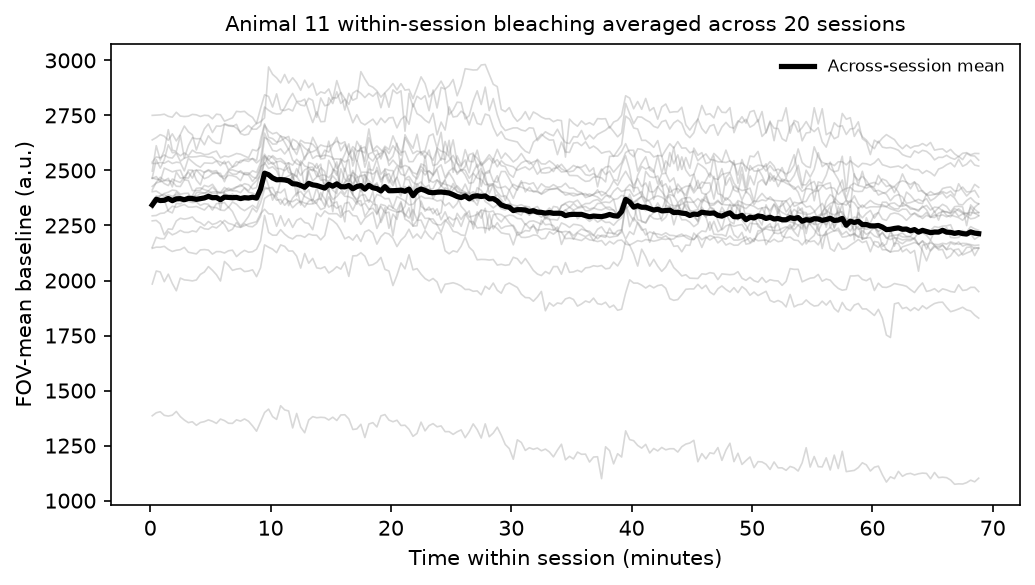

In [7]:
# Set to a tuple of 0-based session indices to highlight only those sessions in color over the gray
# bundle. Leave None to fall back to the across-session mean overlay.
SESSIONS_TO_HIGHLIGHT: tuple[int, ...] | None = None

for animal_id, report in reports.items():
    plot_within_session_average(
        report=report,
        animal_id=animal_id,
        sessions_to_highlight=SESSIONS_TO_HIGHLIGHT,
    )
    plt.show()

### 4.5 Per-cell SNR distributions

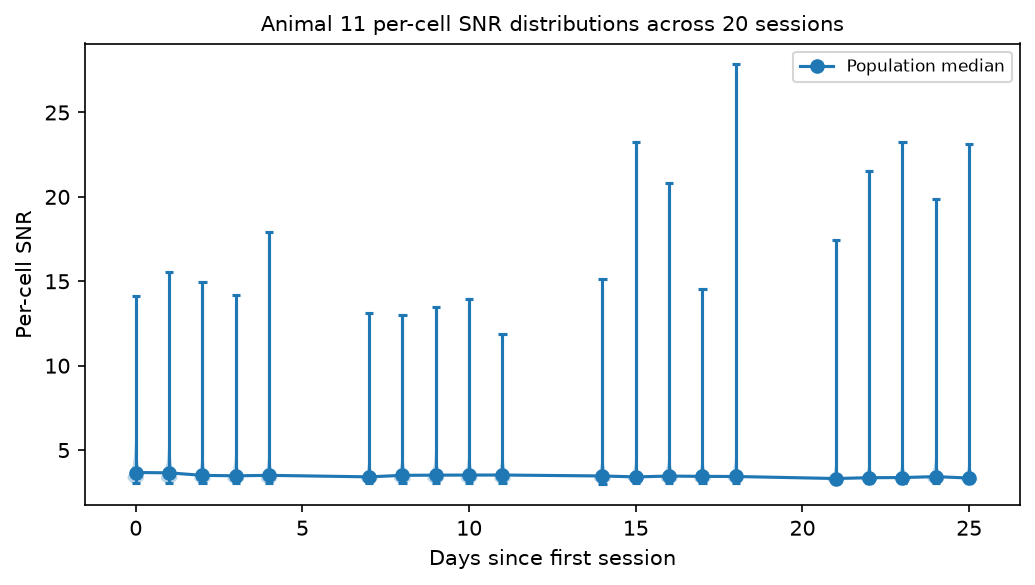

In [8]:
for animal_id, report in reports.items():
    plot_snr_distributions(report=report, animal_id=animal_id)
    plt.show()